# 11 - EfficientNetB0 + 4-Block Transformer Temporal Experiment
## Tai Phake Visual Speech Recognition (VSR) Project

### Experiment Objective & Context
This notebook implements and evaluates a **4-block Transformer temporal sequence model** combined with an ImageNet-pretrained **EfficientNetB0** visual frontend for isolated digit lip reading ($d_0$ through $d_{10}$) in the endangered Tai Phake language.

This experiment is specifically designed for a fair, direct three-way comparison:
1. **EfficientNetB0 + BiLSTM** (Baseline: Recurrent temporal aggregation, 64 hidden units)
2. **EfficientNetB0 + 2-Block Transformer** (Previous experiment: Shallow multi-head self-attention)
3. **EfficientNetB0 + 4-Block Transformer** (**This experiment**: Deeper multi-head self-attention with 4 stacked encoder blocks)

### Experimental Protocol & Fairness Controls
To ensure scientific rigor and unbiased comparative validity, **all experimental variables except Transformer depth are held strictly identical**:
- **Dataset**: Existing **Method D** dataset (96 × 96 letterboxed mouth crops, 30 frames per utterance, RGB 3-channel).
- **Speaker Partitioning**: Strictly speaker-independent split with **zero speaker overlap**:
  - **Validation Speakers** (Clean): `s1`, `s4`, `s21`
  - **Test Speakers** (Clean, isolated): `s8`, `s9`, `s24`
  - **Training Partition**: Multiplied training folders representing canonical base speakers (`s2`, `s3`, `s5`, `s6`, `s7`, `s10`, `s11`, etc.).
  - Note: Multiplied training folders provide training stability without altering the true speaker count. Validation and test sets remain strictly original and clean.
- **Visual Frontend**: ImageNet-pretrained `EfficientNetB0` (`include_top=False`, `pooling='avg'`, outputting a 1280-dimensional feature vector per frame).
- **Temporal Architecture**:
  - TimeDistributed linear projection: $1280 \rightarrow 256$
  - LayerNormalization
  - Deterministic Sinusoidal Positional Encoding
  - **4 stacked Transformer Encoder blocks** (Pre-LN, 4 attention heads, $\text{key\_dim}=64$, $\text{FFN}=512$, GELU activation, $\text{dropout}=0.2$, residual connections)
  - GlobalAveragePooling1D across the 30 temporal frames
  - Dropout (0.4)
  - Dense(11, activation="softmax")
- **Two-Stage Training Protocol**:
  - **Stage 1**: Frozen EfficientNetB0 backbone, Adam (learning rate = $1\times 10^{-4}$), max 40 epochs, EarlyStopping (patience = 8, monitoring `val_loss`, restore best weights), ModelCheckpoint saving best Stage 1 weights.
  - **Stage 2**: Reload best Stage 1 weights, unfreeze the **top 20%** of EfficientNetB0 layers (with all `BatchNormalization` layers kept frozen for stability), Adam (learning rate = $1\times 10^{-5}$), max 25 epochs, EarlyStopping (patience = 6, monitoring `val_loss`, restore best weights), ModelCheckpoint saving best Stage 2 weights.
  - **Loss Function**: Sparse-label-compatible **Label Smoothing** ($0.1$), identical to the best BiLSTM experiment configuration.
- **Evaluation**: The test partition is held completely isolated and evaluated **exactly once** after both training stages conclude.

In [1]:
# =============================================================================
# EXPERIMENT CONFIGURATION
# =============================================================================

DATASET_MODE = "80_20"
# Options:
#   "80_20"   -> 24 base speakers train + 6 base speakers validation
#   "100_3_3" -> use the existing train/val/test processed split

## 2. Imports
Importing core scientific libraries, deep learning frameworks (TensorFlow, Keras), image processing tools, and scikit-learn evaluation metrics.

In [2]:
# Section 2: Imports
import os
import sys
import re
import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import sklearn.metrics as metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf
import keras

print("=" * 80)
print("ENVIRONMENT & DEPENDENCY VERSIONS")
print("=" * 80)
print(f"Python Version:     {sys.version.split()[0]}")
print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version:      {keras.__version__}")
gpu_devices = tf.config.list_physical_devices('GPU')
print(f"Available GPUs:     {len(gpu_devices)} ({gpu_devices})")
print("=" * 80)

ENVIRONMENT & DEPENDENCY VERSIONS
Python Version:     3.12.13
TensorFlow Version: 2.21.0
Keras Version:      3.15.1
Available GPUs:     0 ([])


## 3. Configuration
Defining deterministic random seeds, image and sequence parameters, Transformer architecture hyperparameters (4 encoder blocks), and two-stage training settings.

In [3]:
# Section 3: Configuration & Hyperparameters
SEED = 42

# Reproducibility seeding
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# Sequence & Image Specifications (Method D standard)
NUM_CLASSES = 11
NUM_FRAMES = 30
FRAME_WIDTH = 96
FRAME_HEIGHT = 96
FRAME_CHANNELS = 3
BATCH_SIZE = 16

# Transformer Architecture Hyperparameters (4-Block Configuration)
EMBED_DIM = 256
NUM_HEADS = 4
KEY_DIM = 64          # 4 heads * 64 key_dim = 256
FFN_DIM = 512
NUM_TRANSFORMER_BLOCKS = 4  # 4 stacked Transformer encoder blocks
TRANSFORMER_DROPOUT = 0.2
HEAD_DROPOUT = 0.4

# Two-Stage Training Hyperparameters
STAGE1_LR = 1e-4
STAGE1_MAX_EPOCHS = 40
STAGE1_PATIENCE = 8

STAGE2_LR = 1e-5
STAGE2_MAX_EPOCHS = 25
STAGE2_PATIENCE = 6
FINE_TUNE_FRACTION = 0.20  # Fine-tune last 20% of EfficientNetB0 (not 30%)
LABEL_SMOOTHING = 0.1      # BiLSTM baseline matching label smoothing

# Target Digit Classes (d0 through d10)
DIGIT_CLASSES = [f"d{i}" for i in range(NUM_CLASSES)]
CLASS_TO_ID = {d: i for i, d in enumerate(DIGIT_CLASSES)}
ID_TO_CLASS = {i: d for i, d in enumerate(DIGIT_CLASSES)}

print("=" * 80)
print("EXPERIMENT CONFIGURATION & HYPERPARAMETERS")
print("=" * 80)
print(f"Dataset Mode                 : {DATASET_MODE}")
print(f"Random Seed                  : {SEED}")
print(f"Target Digit Classes ({len(DIGIT_CLASSES)})   : {DIGIT_CLASSES}")
print(f"Input Sequence Shape         : ({NUM_FRAMES} frames, {FRAME_HEIGHT}x{FRAME_WIDTH}, {FRAME_CHANNELS} channels)")
print(f"Batch Size                   : {BATCH_SIZE}")
print(f"Transformer Depth            : {NUM_TRANSFORMER_BLOCKS} Blocks")
print(f"Transformer Attention Heads  : {NUM_HEADS} (key_dim={KEY_DIM}, embed_dim={EMBED_DIM})")
print(f"Transformer FFN Dimension    : {FFN_DIM}")
print(f"Transformer Dropout          : {TRANSFORMER_DROPOUT}")
print(f"Head Dropout                 : {HEAD_DROPOUT}")
print(f"Label Smoothing              : {LABEL_SMOOTHING}")
print(f"Stage 1 Setup                : Adam(lr={STAGE1_LR}), max_epochs={STAGE1_MAX_EPOCHS}, patience={STAGE1_PATIENCE}")
print(f"Stage 2 Setup                : Adam(lr={STAGE2_LR}), max_epochs={STAGE2_MAX_EPOCHS}, patience={STAGE2_PATIENCE}, unfreeze={int(FINE_TUNE_FRACTION*100)}%")
print("=" * 80)

EXPERIMENT CONFIGURATION & HYPERPARAMETERS
Dataset Mode                 : 80_20
Random Seed                  : 42
Target Digit Classes (11)   : ['d0', 'd1', 'd2', 'd3', 'd4', 'd5', 'd6', 'd7', 'd8', 'd9', 'd10']
Input Sequence Shape         : (30 frames, 96x96, 3 channels)
Batch Size                   : 16
Transformer Depth            : 4 Blocks
Transformer Attention Heads  : 4 (key_dim=64, embed_dim=256)
Transformer FFN Dimension    : 512
Transformer Dropout          : 0.2
Head Dropout                 : 0.4
Label Smoothing              : 0.1
Stage 1 Setup                : Adam(lr=0.0001), max_epochs=40, patience=8
Stage 2 Setup                : Adam(lr=1e-05), max_epochs=25, patience=6, unfreeze=20%


## 4. Dataset Paths
Configuring paths for the active Method D processed dataset (`data/processed`) and creating a dedicated output directory for this 4-block Transformer experiment (`results/efficientnetb0_transformer_4block`).

In [4]:
# Section 4: Dataset Paths Configuration
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR

DATA_DIR = PROJECT_ROOT / "data" / "processed"
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

# Dedicated Results Directory per Dataset Mode
RESULTS_DIR = PROJECT_ROOT / "results" / f"efficientnetb0_transformer_4block_{DATASET_MODE}"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

test_path_str = str(TEST_DIR) if DATASET_MODE == "100_3_3" else "DISABLED"

print("=" * 80)
print("DIRECTORY & EXPERIMENT CONFIGURATION")
print("=" * 80)
print(f"Dataset Mode: {DATASET_MODE}")
print(f"Train:        {TRAIN_DIR}")
print(f"Validation:   {VAL_DIR}")
print(f"Test:         {test_path_str}")
print(f"Results:      {RESULTS_DIR}")
print("=" * 80)

DIRECTORY & EXPERIMENT CONFIGURATION
Dataset Mode: 80_20
Train:        /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/data/processed/train
Validation:   /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/data/processed/val
Test:         DISABLED
Results:      /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/efficientnetb0_transformer_4block_80_20


## 5. Speaker Split Verification
Here we inspect the speaker directories across `train/`, `val/`, and `test/`.

**Zero Data Leakage Protocol**:
- Training uses multiplied/duplicated folders (e.g. `s10_aug1` or `s10_dup1`) to stabilize training. We distinguish these duplicated folders from the true underlying base speakers.
- Validation and test partitions contain **only clean, unaugmented original speakers**.
- We assert that there is **strictly zero overlap** between train, validation, and test base speakers.

In [5]:
# Section 5: Speaker Split Verification & Diagnostics
train_speakers = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir() and not d.name.startswith(".")])
val_speakers = sorted([d.name for d in VAL_DIR.iterdir() if d.is_dir() and not d.name.startswith(".")])
test_speakers = sorted([d.name for d in TEST_DIR.iterdir() if d.is_dir() and not d.name.startswith(".")]) if TEST_DIR.exists() else []

def get_base_speaker(spk_name: str) -> str:
    return spk_name.split("_")[0]

base_train_speakers = sorted(
    list({get_base_speaker(s) for s in train_speakers}),
    key=lambda x: int(re.search(r"\d+", x).group(0)) if re.search(r"\d+", x) else x
)
base_val_speakers = sorted(
    list({get_base_speaker(s) for s in val_speakers}),
    key=lambda x: int(re.search(r"\d+", x).group(0)) if re.search(r"\d+", x) else x
)
base_test_speakers = sorted(
    list({get_base_speaker(s) for s in test_speakers}),
    key=lambda x: int(re.search(r"\d+", x).group(0)) if re.search(r"\d+", x) else x
)

test_diag_str = (
    f"{len(base_test_speakers)} base speakers / {len(test_speakers)} directories"
    if DATASET_MODE == "100_3_3"
    else "DISABLED (0 speakers / 0 directories)"
)

print("=" * 80)
print(f"SPEAKER PARTITION DIAGNOSTICS [Mode: {DATASET_MODE}]")
print("=" * 80)
print(f"Dataset Mode:                    {DATASET_MODE}")
print(f"Training speakers/directories:   {len(base_train_speakers)} base speakers / {len(train_speakers)} directories")
print(f"Validation speakers/directories: {len(base_val_speakers)} base speakers / {len(val_speakers)} directories")
print(f"Test speakers/directories:       {test_diag_str}")
print("-" * 80)

set_train_base = set(base_train_speakers)
set_val_base = set(base_val_speakers)
set_test_base = set(base_test_speakers)

if DATASET_MODE == "80_20":
    # 80/20 Mode Assertions (24 train base, 6 val base, 0 test)
    assert len(set_train_base.intersection(set_val_base)) == 0, (
        f"DATA LEAKAGE: Overlap between Train and Val base speakers: {set_train_base.intersection(set_val_base)}"
    )

    assert len(base_train_speakers) == 24, (
        f"Expected 24 base train speakers in 80/20 mode, found {len(base_train_speakers)}"
    )
    assert len(base_val_speakers) == 6, (
        f"Expected 6 base val speakers in 80/20 mode, found {len(base_val_speakers)}"
    )

    for s in train_speakers:
        assert get_base_speaker(s) in set_train_base, f"DATA LEAKAGE: Folder {s} not in train base speakers!"
    for s in val_speakers:
        assert get_base_speaker(s) in set_val_base, f"DATA LEAKAGE: Folder {s} not in val base speakers!"

    assert len(test_speakers) == 0, f"DATA LEAKAGE: Test folder should be empty in 80/20 mode, found {test_speakers}"

    print("")
    print("[SUCCESS] ALL STRICT ZERO-LEAKAGE ASSERTIONS PASSED (80_20 Mode):")
    print("  [x] Train & Val base speakers: Zero overlap")
    print(f"  [x] Exactly 24 base train speakers ({len(train_speakers)} directories)")
    print(f"  [x] Exactly 6 base val speakers ({len(val_speakers)} directories)")
    print("  [x] Test split: Cleanly disabled / empty")

elif DATASET_MODE == "100_3_3":
    # 100_3_3 Canonical Assertions
    EXPECTED_VAL_SPEAKERS = {"s1", "s4", "s21"}
    EXPECTED_TEST_SPEAKERS = {"s8", "s9", "s24"}

    assert len(set_train_base.intersection(set_val_base)) == 0, (
        f"DATA LEAKAGE: Overlap between Train and Val speakers: {set_train_base.intersection(set_val_base)}"
    )
    assert len(set_train_base.intersection(set_test_base)) == 0, (
        f"DATA LEAKAGE: Overlap between Train and Test speakers: {set_train_base.intersection(set_test_base)}"
    )
    assert len(set_val_base.intersection(set_test_base)) == 0, (
        f"DATA LEAKAGE: Overlap between Val and Test speakers: {set_val_base.intersection(set_test_base)}"
    )

    for s in val_speakers:
        assert "_" not in s, f"DATA LEAKAGE: Multiplied folder '{s}' found in validation partition!"
    for s in test_speakers:
        assert "_" not in s, f"DATA LEAKAGE: Multiplied folder '{s}' found in test partition!"

    assert set(val_speakers) == EXPECTED_VAL_SPEAKERS, (
        f"Validation speakers mismatch! Expected {EXPECTED_VAL_SPEAKERS}, found {set(val_speakers)}"
    )
    assert set(test_speakers) == EXPECTED_TEST_SPEAKERS, (
        f"Test speakers mismatch! Expected {EXPECTED_TEST_SPEAKERS}, found {set(test_speakers)}"
    )

    print("")
    print("[SUCCESS] ALL 7 STRICT ZERO-LEAKAGE ASSERTIONS PASSED (100_3_3 Mode):")
    print("  [x] Train & Val base speakers: Zero overlap")
    print("  [x] Train & Test base speakers: Zero overlap")
    print("  [x] Val & Test speakers: Zero overlap")
    print("  [x] Validation partition: 100% clean original speakers")
    print("  [x] Test partition: 100% clean original speakers")
    print(f"  [x] Canonical Validation Set: {EXPECTED_VAL_SPEAKERS}")
    print(f"  [x] Canonical Test Set: {EXPECTED_TEST_SPEAKERS}")

else:
    raise ValueError(f"Unknown DATASET_MODE: '{DATASET_MODE}'. Options are '80_20' or '100_3_3'.")

# Save speaker split metadata
split_metadata = {
    "dataset_mode": DATASET_MODE,
    "random_seed": SEED,
    "num_train_folders": len(train_speakers),
    "num_base_train_speakers": len(base_train_speakers),
    "num_val_folders": len(val_speakers),
    "num_base_val_speakers": len(base_val_speakers),
    "num_test_folders": len(test_speakers),
    "num_base_test_speakers": len(base_test_speakers),
    "base_train_speakers": base_train_speakers,
    "train_speakers": train_speakers,
    "base_val_speakers": base_val_speakers,
    "val_speakers": val_speakers,
    "base_test_speakers": base_test_speakers,
    "test_speakers": test_speakers,
}
with open(RESULTS_DIR / "speaker_split.json", "w") as f:
    json.dump(split_metadata, f, indent=2)
print(f"Speaker partition metadata saved to: {RESULTS_DIR / 'speaker_split.json'}")

SPEAKER PARTITION DIAGNOSTICS [Mode: 80_20]
Dataset Mode:                    80_20
Training speakers/directories:   24 base speakers / 80 directories
Validation speakers/directories: 6 base speakers / 20 directories
Test speakers/directories:       DISABLED (0 speakers / 0 directories)
--------------------------------------------------------------------------------

[SUCCESS] ALL STRICT ZERO-LEAKAGE ASSERTIONS PASSED (80_20 Mode):
  [x] Train & Val base speakers: Zero overlap
  [x] Exactly 24 base train speakers (80 directories)
  [x] Exactly 6 base val speakers (20 directories)
  [x] Test split: Cleanly disabled / empty
Speaker partition metadata saved to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/efficientnetb0_transformer_4block_80_20/speaker_split.json


## 6. Manifest Creation
Indexing all video utterance sequences across train, val, and test splits into a unified manifest dataframe.

In [6]:
# Section 6: Manifest Creation
def natural_sort_key(p):
    m = re.search(r"(\d+)", Path(p).stem)
    return int(m.group(1)) if m else 0

split_dirs = {"train": TRAIN_DIR, "val": VAL_DIR}
if DATASET_MODE == "100_3_3":
    split_dirs["test"] = TEST_DIR

utterances = []

for split_name, s_dir in split_dirs.items():
    if not s_dir.exists():
        continue
    spk_dirs = sorted([d for d in s_dir.iterdir() if d.is_dir() and not d.name.startswith(".")])
    for s_path in spk_dirs:
        spk = s_path.name
        base_spk = get_base_speaker(spk)
        for digit in DIGIT_CLASSES:
            digit_dir = s_path / digit
            if not digit_dir.exists():
                continue
            frames = sorted(list(digit_dir.glob("*.jpg")), key=natural_sort_key)
            if len(frames) == 0:
                continue
            utterances.append({
                "speaker": spk,
                "base_speaker": base_spk,
                "digit": digit,
                "digit_id": CLASS_TO_ID[digit],
                "split": split_name,
                "raw_frame_count": len(frames),
                "frame_paths": frames
            })

df_manifest = pd.DataFrame(utterances)

test_count_str = (
    f"{len(df_manifest[df_manifest['split']=='test']):,} utterances ({len(test_speakers)} folders, {len(base_test_speakers)} base speakers)"
    if DATASET_MODE == "100_3_3"
    else "DISABLED (no test split)"
)

print("=" * 80)
print(f"UTTERANCE MANIFEST SUMMARY [Mode: {DATASET_MODE}]")
print("=" * 80)
print(f"Total Utterances Indexed: {len(df_manifest):,}")
print(f"  Train Split : {len(df_manifest[df_manifest['split']=='train']):,} utterances ({len(train_speakers)} folders, {len(base_train_speakers)} base speakers)")
print(f"  Val Split   : {len(df_manifest[df_manifest['split']=='val']):,} utterances ({len(val_speakers)} folders, {len(base_val_speakers)} base speakers)")
print(f"  Test Split  : {test_count_str}")
print("=" * 80)

# Save manifest to CSV
manifest_csv_path = RESULTS_DIR / "utterance_manifest.csv"
df_manifest[["speaker", "base_speaker", "digit", "digit_id", "split", "raw_frame_count"]].to_csv(
    manifest_csv_path, index=False
)
print(f"Manifest saved to: {manifest_csv_path}")

UTTERANCE MANIFEST SUMMARY [Mode: 80_20]
Total Utterances Indexed: 1,100
  Train Split : 880 utterances (80 folders, 24 base speakers)
  Val Split   : 220 utterances (20 folders, 6 base speakers)
  Test Split  : DISABLED (no test split)
Manifest saved to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/efficientnetb0_transformer_4block_80_20/utterance_manifest.csv


## 7. Frame Sampling & In-Memory Loading
Temporal standardization and in-memory tensor construction:
1. Each video utterance is deterministically sampled to exactly **30 frames** using uniform linear interpolation across the raw frame timeline (`np.linspace`).
2. The sampled 30 frames are loaded as 96 × 96 RGB images in `[0.0, 255.0]` float32 format.
3. Sequences are partitioned into train, validation, and test tensors.

In [7]:
# Section 7: Frame Sampling & In-Memory Sequence Loading
def sample_30_frames(frame_paths: list, target_frames: int = NUM_FRAMES) -> list:
    """
    Deterministic temporal sampling across the video duration.
    Produces exactly target_frames (30) uniformly distributed frame indices.
    """
    n = len(frame_paths)
    if n == target_frames:
        indices = list(range(target_frames))
    else:
        indices = np.round(np.linspace(0, n - 1, target_frames)).astype(int)
    return [str(frame_paths[i]) for i in indices]

# EXPERIMENT 1 IMPLEMENTATION: dropping 3 frames
# def sample_30_frames(frame_paths: list, target_frames: int = NUM_FRAMES, drop_start: int = 3, drop_end: int = 3) -> list:
#     n = len(frame_paths)
#     # Drop first 3 and last 3 frames (neutral / closed lips)
#     if n > (drop_start + drop_end):
#         trimmed = frame_paths[drop_start:-drop_end]
#     else:
#         trimmed = frame_paths

#     n_trimmed = len(trimmed)
#     if n_trimmed == target_frames:
#         indices = list(range(target_frames))
#     else:
#         indices = np.round(np.linspace(0, n_trimmed - 1, target_frames)).astype(int)
#     return [str(trimmed[i]) for i in indices]


df_manifest["sampled_frame_paths"] = df_manifest["frame_paths"].apply(sample_30_frames)
print(f"Standardized all {len(df_manifest):,} utterances to exactly {NUM_FRAMES} frames.")

def load_all_video_sequences():
    """
    Loads all sampled frames into contiguous NumPy tensors.
    """
    X_data = np.zeros(
        (len(df_manifest), NUM_FRAMES, FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS),
        dtype=np.float32
    )
    y_data = np.array(df_manifest["digit_id"].values, dtype=np.int32)

    t0 = time.time()
    for i, row in df_manifest.iterrows():
        for t, fpath in enumerate(row["sampled_frame_paths"]):
            img = Image.open(fpath).convert("RGB")
            if img.size != (FRAME_WIDTH, FRAME_HEIGHT):
                img = img.resize((FRAME_WIDTH, FRAME_HEIGHT), Image.BILINEAR)
            X_data[i, t] = np.array(img, dtype=np.float32)

    elapsed = time.time() - t0
    return X_data, y_data, elapsed

print("Loading video sequence tensors into memory...")
X_all, y_all, load_elapsed = load_all_video_sequences()

# Split into train, val, test arrays
train_mask = (df_manifest["split"] == "train").values
val_mask = (df_manifest["split"] == "val").values

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_val, y_val = X_all[val_mask], y_all[val_mask]

if DATASET_MODE == "100_3_3":
    test_mask = (df_manifest["split"] == "test").values
    X_test, y_test = X_all[test_mask], y_all[test_mask]
else:
    X_test, y_test = None, None

print(f"Successfully loaded {len(X_all):,} video sequences in {load_elapsed:.2f}s!")

Standardized all 1,100 utterances to exactly 30 frames.
Loading video sequence tensors into memory...
Successfully loaded 1,100 video sequences in 5.40s!


## 8. Dataset Statistics & Sanity Checks
Validating data shapes, memory footprints, intensity ranges, and ensuring zero NaNs/Infs and full class balance.

In [8]:
# Section 8: Dataset Statistics & Sanity Verification
print("=" * 80)
print(f"DATASET TENSOR STATISTICS & INTEGRITY [Mode: {DATASET_MODE}]")
print("=" * 80)
print(f"X_all Shape                 : {X_all.shape}")
print(f"Memory Footprint            : {X_all.nbytes / (1024**2):.1f} MB")
print(f"Pixel Intensity Range       : [{X_all.min():.1f}, {X_all.max():.1f}]")
print(f"X_train Shape               : {X_train.shape} | y_train: {y_train.shape}")
print(f"X_val Shape                 : {X_val.shape}   | y_val:   {y_val.shape}")
if DATASET_MODE == "100_3_3" and X_test is not None:
    print(f"X_test Shape                : {X_test.shape}  | y_test:  {y_test.shape}")
else:
    print("X_test Shape                : DISABLED (no test split in 80/20 mode)")
print("-" * 80)

# Shape assertions
assert X_train.shape[1:] == (NUM_FRAMES, FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS), f"Unexpected X_train shape: {X_train.shape}"
assert X_val.shape[1:] == (NUM_FRAMES, FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS), f"Unexpected X_val shape: {X_val.shape}"

# Numerical validity
assert not np.isnan(X_train).any(), "NaN values detected in X_train!"
assert not np.isnan(X_val).any(), "NaN values detected in X_val!"

assert not np.isinf(X_train).any(), "Inf values detected in X_train!"
assert not np.isinf(X_val).any(), "Inf values detected in X_val!"

# Class representation
assert set(np.unique(y_train)) == set(range(NUM_CLASSES)), "Missing classes in train split!"
assert set(np.unique(y_val)) == set(range(NUM_CLASSES)), "Missing classes in validation split!"

if DATASET_MODE == "100_3_3" and X_test is not None:
    assert X_test.shape[1:] == (NUM_FRAMES, FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS), f"Unexpected X_test shape: {X_test.shape}"
    assert not np.isnan(X_test).any(), "NaN values detected in X_test!"
    assert not np.isinf(X_test).any(), "Inf values detected in X_test!"
    assert set(np.unique(y_test)) == set(range(NUM_CLASSES)), "Missing classes in test split!"

print("Sanity Checks Passed:")
print(f"  [x] Expected sequence dimensions ({NUM_FRAMES}, {FRAME_HEIGHT}, {FRAME_WIDTH}, {FRAME_CHANNELS}) confirmed")
print("  [x] Zero NaN and zero Inf values confirmed across active splits")
print(f"  [x] All {NUM_CLASSES} digit classes (d0..d10) fully represented across active splits")
print("=" * 80)

DATASET TENSOR STATISTICS & INTEGRITY [Mode: 80_20]
X_all Shape                 : (1100, 30, 96, 96, 3)
Memory Footprint            : 3480.5 MB
Pixel Intensity Range       : [0.0, 255.0]
X_train Shape               : (880, 30, 96, 96, 3) | y_train: (880,)
X_val Shape                 : (220, 30, 96, 96, 3)   | y_val:   (220,)
X_test Shape                : DISABLED (no test split in 80/20 mode)
--------------------------------------------------------------------------------
Sanity Checks Passed:
  [x] Expected sequence dimensions (30, 96, 96, 3) confirmed
  [x] Zero NaN and zero Inf values confirmed across active splits
  [x] All 11 digit classes (d0..d10) fully represented across active splits


## 9. Sinusoidal Positional Encoding
Standard deterministic sinusoidal positional encoding (Vaswani et al., 2017) applied to the 30-frame temporal dimension ($T=30$, $D=256$):
$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d}}\right), \quad PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d}}\right)$$

In [9]:
# Section 9: Sinusoidal Positional Encoding Layer
class PositionalEncoding(keras.layers.Layer):
    """
    Sinusoidal positional encoding layer for sequence length T=30 and embed_dim=256.
    Adds a fixed, non-trainable (1, T, D) positional encoding tensor to the input.
    """
    def __init__(self, seq_len: int = NUM_FRAMES, dim: int = EMBED_DIM, **kwargs):
        super().__init__(**kwargs)
        self.seq_len = seq_len
        self.dim = dim

        pos = np.arange(seq_len)[:, np.newaxis]
        i = np.arange(dim)[np.newaxis, :]
        angles = pos / np.power(10000.0, (2 * (i // 2)) / np.float32(dim))

        pe = np.zeros((1, seq_len, dim), dtype=np.float32)
        pe[0, :, 0::2] = np.sin(angles[:, 0::2])
        pe[0, :, 1::2] = np.cos(angles[:, 1::2])
        self.pe = tf.constant(pe, dtype=tf.float32)

    def call(self, inputs):
        return inputs + self.pe

    def get_config(self):
        config = super().get_config()
        config.update({"seq_len": self.seq_len, "dim": self.dim})
        return config

# Verification
pe_test = PositionalEncoding(seq_len=NUM_FRAMES, dim=EMBED_DIM)
dummy_tensor = tf.zeros((1, NUM_FRAMES, EMBED_DIM))
encoded_tensor = pe_test(dummy_tensor)
assert encoded_tensor.shape == (1, NUM_FRAMES, EMBED_DIM), f"Unexpected shape: {encoded_tensor.shape}"
print(f"PositionalEncoding verified: output shape {encoded_tensor.shape} matches expected (1, {NUM_FRAMES}, {EMBED_DIM}).")

PositionalEncoding verified: output shape (1, 30, 256) matches expected (1, 30, 256).


## 10. Transformer Encoder Block
Clean Pre-LayerNormalization (Pre-LN) Transformer encoder block operating along the temporal dimension ($T=30$):
1. **Multi-Head Attention**:
   - `LayerNormalization(epsilon=1e-6)`
   - `MultiHeadAttention(num_heads=4, key_dim=64, dropout=0.2)`
   - Dropout (`0.2`)
   - Residual connection (`Add`)
2. **Feed-Forward Network (FFN)**:
   - `LayerNormalization(epsilon=1e-6)`
   - `Dense(512, activation="gelu")`
   - Dropout (`0.2`)
   - `Dense(256)`
   - Dropout (`0.2`)
   - Residual connection (`Add`)

In [10]:
# Section 10: Transformer Encoder Block
def transformer_encoder_block(
    x,
    embed_dim: int = EMBED_DIM,
    num_heads: int = NUM_HEADS,
    key_dim: int = KEY_DIM,
    ffn_dim: int = FFN_DIM,
    dropout: float = TRANSFORMER_DROPOUT,
    block_id: int = 1
):
    """
    Reusable Pre-LN Transformer Encoder Block operating across the 30-frame temporal dimension.
    """
    # 1. Multi-Head Self-Attention branch (Pre-LN)
    norm1 = keras.layers.LayerNormalization(epsilon=1e-6, name=f"transformer_{block_id}_norm1")(x)
    attn = keras.layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=key_dim,
        dropout=dropout,
        name=f"transformer_{block_id}_mha"
    )(norm1, norm1)
    attn = keras.layers.Dropout(dropout, name=f"transformer_{block_id}_attn_drop")(attn)
    x = keras.layers.Add(name=f"transformer_{block_id}_add1")([x, attn])

    # 2. Feed-Forward Network branch (Pre-LN)
    norm2 = keras.layers.LayerNormalization(epsilon=1e-6, name=f"transformer_{block_id}_norm2")(x)
    ffn = keras.layers.Dense(ffn_dim, activation="gelu", name=f"transformer_{block_id}_ffn1")(norm2)
    ffn = keras.layers.Dropout(dropout, name=f"transformer_{block_id}_ffn_drop1")(ffn)
    ffn = keras.layers.Dense(embed_dim, name=f"transformer_{block_id}_ffn2")(ffn)
    ffn = keras.layers.Dropout(dropout, name=f"transformer_{block_id}_ffn_drop2")(ffn)
    x = keras.layers.Add(name=f"transformer_{block_id}_add2")([x, ffn])

    return x

print("Transformer Encoder Block definition verified.")

Transformer Encoder Block definition verified.


## 11. EfficientNetB0 + 4-Block Transformer Model
Building the end-to-end architecture:
```
Input: (30, 96, 96, 3)
   ↓
TimeDistributed EfficientNetB0 (preprocess_input + ImageNet backbone)
   ↓
1280-dimensional feature vector per frame
   ↓
Dense(256)
   ↓
LayerNormalization
   ↓
Sinusoidal Positional Encoding
   ↓
4 × Transformer Encoder Blocks (Pre-LN, 4 heads, key_dim=64, FFN=512)
   ↓
GlobalAveragePooling1D
   ↓
Dropout(0.4)
   ↓
Dense(11, activation="softmax")
```

In [11]:
# Section 11: End-to-End Model Assembly
def get_efficientnetb0_backbone():
    """
    Builds the EfficientNetB0 visual feature extractor.
    """
    cnn = keras.applications.EfficientNetB0(
        input_shape=(FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS),
        include_top=False,
        weights="imagenet",
        pooling="avg"
    )
    preprocess_fn = keras.applications.efficientnet.preprocess_input
    return cnn, preprocess_fn

def build_efficientnet_transformer_4block():
    """
    Constructs the complete EfficientNetB0 + 4-Block Transformer architecture.
    """
    cnn, preprocess_fn = get_efficientnetb0_backbone()

    # Input: (batch, 30, 96, 96, 3)
    inputs = keras.layers.Input(
        shape=(NUM_FRAMES, FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS),
        name="lip_sequence_input"
    )

    # 1. Image preprocessing inside the Keras computational graph
    x = keras.layers.TimeDistributed(
        keras.layers.Lambda(preprocess_fn),
        name="efficientnetb0_preprocess"
    )(inputs)

    # 2. Frame-level feature extraction via EfficientNetB0 (yields 1280 features per frame)
    x = keras.layers.TimeDistributed(cnn, name="efficientnetb0_cnn")(x)  # (batch, 30, 1280)

    # 3. Dense Projection to embedding dimension 256
    x = keras.layers.TimeDistributed(
        keras.layers.Dense(EMBED_DIM, use_bias=False),
        name="projection_dense"
    )(x)  # (batch, 30, 256)
    x = keras.layers.LayerNormalization(epsilon=1e-6, name="projection_ln")(x)

    # 4. Sinusoidal Positional Encoding
    x = PositionalEncoding(seq_len=NUM_FRAMES, dim=EMBED_DIM, name="positional_encoding")(x)

    # 5. 4x Transformer Encoder Blocks
    for b_id in range(1, NUM_TRANSFORMER_BLOCKS + 1):
        x = transformer_encoder_block(
            x,
            embed_dim=EMBED_DIM,
            num_heads=NUM_HEADS,
            key_dim=KEY_DIM,
            ffn_dim=FFN_DIM,
            dropout=TRANSFORMER_DROPOUT,
            block_id=b_id
        )

    # 6. Temporal Sequence Pooling
    x = keras.layers.GlobalAveragePooling1D(name="gap1d")(x)  # (batch, 256)

    # 7. Classification Head
    x = keras.layers.Dropout(HEAD_DROPOUT, name="head_dropout")(x)
    outputs = keras.layers.Dense(NUM_CLASSES, activation="softmax", name="digit_classifier")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="EfficientNetB0_Transformer_4Block")
    return model, cnn

print("Architecture builders defined.")

Architecture builders defined.


## 12. Model Summary
Instantiating the model, inspecting its layer hierarchy, and verifying a forward pass on a synthetic input batch.

In [12]:
# Section 12: Model Summary & Forward Pass Verification
model, cnn = build_efficientnet_transformer_4block()

print("=" * 80)
print("             EFFICIENTNETB0 + 4-BLOCK TRANSFORMER ARCHITECTURE")
print("=" * 80)
model.summary()

# Forward pass validation on a dummy input batch
dummy_batch = tf.random.uniform((2, NUM_FRAMES, FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS), 0.0, 255.0)
dummy_out = model(dummy_batch, training=False)

assert dummy_out.shape == (2, NUM_CLASSES), f"Unexpected output shape: {dummy_out.shape}"
print(f"\n[SUCCESS] Forward pass verification passed! Output shape: {dummy_out.shape} for input (2, 30, 96, 96, 3)")

             EFFICIENTNETB0 + 4-BLOCK TRANSFORMER ARCHITECTURE


Model: "EfficientNetB0_Transformer_4Block"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ lip_sequence_input  │ (None, 30, 96,    │          0 │ -                 │
│ (InputLayer)        │ 96, 3)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0_pre… │ (None, 30, 96,    │          0 │ lip_sequence_inp… │
│ (TimeDistributed)   │ 96, 3)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0_cnn  │ (None, 30, 1280)  │  4,049,571 │ efficientnetb0_p… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ projection_dense    │ (None, 30, 256)   │    327,680 │ efficientnetb0_c… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ projection_ln       │ (None, 30, 256)   │        512 │ projection_dense… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encoding │ (None, 30, 256)   │          0 │ projection_ln[0]… │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_1_norm1 │ (None, 30, 256)   │        512 │ positional_encod… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_1_mha   │ (None, 30, 256)   │    263,168 │ transformer_1_no… │
│ (MultiHeadAttentio… │                   │            │ transformer_1_no… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_1_attn… │ (None, 30, 256)   │          0 │ transformer_1_mh… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_1_add1  │ (None, 30, 256)   │          0 │ positional_encod… │
│ (Add)               │                   │            │ transformer_1_at… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_1_norm2 │ (None, 30, 256)   │        512 │ transformer_1_ad… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_1_ffn1  │ (None, 30, 512)   │    131,584 │ transformer_1_no… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_1_ffn_… │ (None, 30, 512)   │          0 │ transformer_1_ff… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_1_ffn2  │ (None, 30, 256)   │    131,328 │ transformer_1_ff… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_1_ffn_… │ (None, 30, 256)   │          0 │ transformer_1_ff… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_1_add2  │ (None, 30, 256)   │          0 │ transformer_1_ad… │
│ (Add)               │                   │            │ transformer_1_ff… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_2_norm1 │ (None, 30, 256)   │        512 │ transformer_1_ad

 Total params: 6,489,006 (24.75 MB)

 Trainable params: 6,446,983 (24.59 MB)

 Non-trainable params: 42,023 (164.16 KB)


[SUCCESS] Forward pass verification passed! Output shape: (2, 11) for input (2, 30, 96, 96, 3)


## 13. Stage 1 Training: Frozen EfficientNetB0
- EfficientNetB0 backbone is **completely frozen** (`trainable = False`).
- Transformer blocks, projection layer, and classification head are trainable.
- Optimizer: **Adam** (learning rate = $1\times 10^{-4}$).
- Loss: **Sparse-label-compatible Label Smoothing** ($0.1$).
- Maximum epochs: 40, EarlyStopping patience = 8 monitoring `val_loss`.
- ModelCheckpoint preserves the best Stage 1 weights.

In [13]:
# Section 13: Stage 1 Training (Frozen EfficientNetB0)
def sparse_label_smoothing_loss(smoothing=LABEL_SMOOTHING):
    """
    Sparse-label-compatible cross-entropy loss with label smoothing.
    Matches the formulation from the baseline BiLSTM experiment.
    """
    def loss_fn(y_true, y_pred):
        num_classes = tf.shape(y_pred)[-1]
        y_true = tf.cast(y_true, tf.int32)

        y_true_one_hot = tf.one_hot(
            y_true,
            depth=num_classes
        )

        y_true_smooth = (
            y_true_one_hot * (1.0 - smoothing)
            + smoothing / tf.cast(num_classes, tf.float32)
        )

        return tf.keras.losses.categorical_crossentropy(
            y_true_smooth,
            y_pred
        )

    return loss_fn

def freeze_all_cnn_layers(backbone):
    backbone.trainable = False
    for layer in backbone.layers:
        layer.trainable = False

# Freeze entire CNN backbone for Stage 1
freeze_all_cnn_layers(cnn)

# Compile model for Stage 1
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=STAGE1_LR),
    loss=sparse_label_smoothing_loss(LABEL_SMOOTHING),
    metrics=["accuracy"]
)

stage1_weights_path = RESULTS_DIR / "efficientnetb0_transformer_4block_stage1_best.weights.h5"

checkpoint1 = keras.callbacks.ModelCheckpoint(
    stage1_weights_path,
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

early1 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=STAGE1_PATIENCE,
    restore_best_weights=True,
    verbose=1
)

print("=" * 80)
print(f"STARTING STAGE 1 TRAINING: Frozen EfficientNetB0 (lr={STAGE1_LR}, max_epochs={STAGE1_MAX_EPOCHS})")
print(f"Train samples: {len(X_train):,} | Validation samples: {len(X_val):,}")
print("=" * 80)

t_stage1_start = time.time()
history1 = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=STAGE1_MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=[checkpoint1, early1],
    verbose=1
)
stage1_elapsed = time.time() - t_stage1_start

# Ensure best weights are restored
if stage1_weights_path.exists():
    model.load_weights(stage1_weights_path)

stage1_best_epoch = int(np.argmin(history1.history["val_loss"]) + 1)
stage1_best_val_acc = float(max(history1.history["val_accuracy"]))
stage1_best_val_loss = float(min(history1.history["val_loss"]))

print("-" * 80)
print(f"Stage 1 Completed in {stage1_elapsed:.2f}s")
print(f"Stage 1 Best Epoch            : {stage1_best_epoch}")
print(f"Stage 1 Best Validation Loss  : {stage1_best_val_loss:.4f}")
print(f"Stage 1 Best Validation Acc   : {stage1_best_val_acc * 100:.2f}%")
print("=" * 80)

STARTING STAGE 1 TRAINING: Frozen EfficientNetB0 (lr=0.0001, max_epochs=40)
Train samples: 880 | Validation samples: 220
Epoch 1/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 589ms/step - accuracy: 0.1136 - loss: 4.3862
Epoch 1: val_loss improved from None to 3.14354, saving model to /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/efficientnetb0_transformer_4block_80_20/efficientnetb0_transformer_4block_stage1_best.weights.h5

Epoch 1: finished saving model to /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/efficientnetb0_transformer_4block_80_20/efficientnetb0_transformer_4block_stage1_best.weights.h5
55/55 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.1136 - loss: 4.3862 - val_accuracy: 0.1591 - val_loss: 3.1435
Epoch 2/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - accuracy: 0.2159 - loss: 2.9259
Epoch 2: val_loss improved from 3.14354 to 2.82601, saving model to /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/efficientnetb0_t

## 14. Stage 2 Fine-Tuning: Unfreezing Last 20% of EfficientNetB0
- Reload best Stage 1 weights.
- Unfreeze the **top 20%** of EfficientNetB0 layers (`fraction=0.20`), keeping all `BatchNormalization` layers frozen for training stability.
- Transformer encoder blocks and classification head remain trainable.
- Optimizer: **Adam** (learning rate = $1\times 10^{-5}$).
- Loss: **Sparse-label-compatible Label Smoothing** ($0.1$).
- Maximum epochs: 25, EarlyStopping patience = 6 monitoring `val_loss`.
- ModelCheckpoint preserves the best Stage 2 weights.

In [14]:
# Section 14: Stage 2 Fine-Tuning (Top 20% EfficientNetB0, BatchNorm Frozen)
# 1. Reload best Stage-1 weights
if stage1_weights_path.exists():
    model.load_weights(stage1_weights_path)
    print("Reloaded best Stage 1 weights.")

def unfreeze_last_fraction(backbone, fraction=FINE_TUNE_FRACTION):
    # Freeze all layers first
    for layer in backbone.layers:
        layer.trainable = False

    total_layers = len(backbone.layers)
    start_index = int(total_layers * (1.0 - fraction))

    for layer in backbone.layers[start_index:]:
        # Keep BatchNormalization frozen for training stability
        if not isinstance(layer, keras.layers.BatchNormalization):
            layer.trainable = True

# Unfreeze top 20% of EfficientNetB0
unfreeze_last_fraction(cnn, fraction=FINE_TUNE_FRACTION)

# Re-compile with fine-tuning learning rate (1e-5)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=STAGE2_LR),
    loss=sparse_label_smoothing_loss(LABEL_SMOOTHING),
    metrics=["accuracy"]
)

stage2_trainable_params = int(np.sum([np.prod(v.shape) for v in model.trainable_weights]))
print(f"Trainable parameters during Stage 2 Fine-Tuning: {stage2_trainable_params:,}")

stage2_weights_path = RESULTS_DIR / "efficientnetb0_transformer_4block_stage2_best.weights.h5"

checkpoint2 = keras.callbacks.ModelCheckpoint(
    stage2_weights_path,
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

early2 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=STAGE2_PATIENCE,
    restore_best_weights=True,
    verbose=1
)

print("=" * 80)
print(f"STARTING STAGE 2 FINE-TUNING (lr={STAGE2_LR}, max_epochs={STAGE2_MAX_EPOCHS})")
print("=" * 80)

t_stage2_start = time.time()
history2 = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=STAGE2_MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=[checkpoint2, early2],
    verbose=1
)
stage2_elapsed = time.time() - t_stage2_start

# Ensure best fine-tuned weights are restored
if stage2_weights_path.exists():
    model.load_weights(stage2_weights_path)

stage2_best_epoch = int(np.argmin(history2.history["val_loss"]) + 1)
stage2_best_val_acc = float(max(history2.history["val_accuracy"]))
stage2_best_val_loss = float(min(history2.history["val_loss"]))

print("-" * 80)
print(f"Stage 2 Completed in {stage2_elapsed:.2f}s")
print(f"Stage 2 Best Epoch            : {stage2_best_epoch}")
print(f"Stage 2 Best Validation Loss  : {stage2_best_val_loss:.4f}")
print(f"Stage 2 Best Validation Acc   : {stage2_best_val_acc * 100:.2f}%")
print("=" * 80)

Reloaded best Stage 1 weights.
Trainable parameters during Stage 2 Fine-Tuning: 4,726,939
STARTING STAGE 2 FINE-TUNING (lr=1e-05, max_epochs=25)
Epoch 1/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 742ms/step - accuracy: 0.8920 - loss: 0.9181
Epoch 1: val_loss improved from None to 2.03068, saving model to /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/efficientnetb0_transformer_4block_80_20/efficientnetb0_transformer_4block_stage2_best.weights.h5

Epoch 1: finished saving model to /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/efficientnetb0_transformer_4block_80_20/efficientnetb0_transformer_4block_stage2_best.weights.h5
55/55 ━━━━━━━━━━━━━━━━━━━━ 178s 1s/step - accuracy: 0.8920 - loss: 0.9181 - val_accuracy: 0.5273 - val_loss: 2.0307
Epoch 2/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 784ms/step - accuracy: 0.9284 - loss: 0.8681
Epoch 2: val_loss did not improve from 2.03068
55/55 ━━━━━━━━━━━━━━━━━━━━ 50s 920ms/step - accuracy: 0.9284 - loss: 0.8681 - val_ac

## 15. Training & Validation Curves
Concatenating Stage 1 and Stage 2 histories, plotting loss and accuracy trajectories with a stage transition boundary, and persisting the curves to disk.

Training history saved to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/efficientnetb0_transformer_4block_80_20/training_history.csv


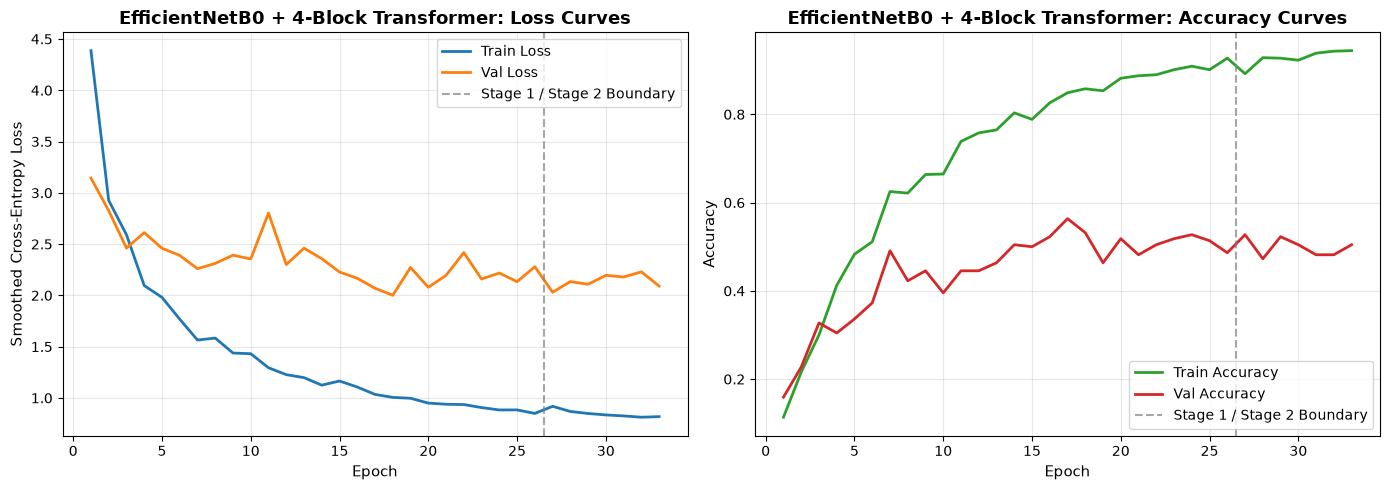

Training curves saved to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/efficientnetb0_transformer_4block_80_20/training_history_curves.png


In [15]:
# Section 15: Training History Compilation & Visualization
h1 = history1.history
h2 = history2.history

combined_history = {
    "epoch": list(range(1, len(h1["loss"]) + len(h2["loss"]) + 1)),
    "stage": ["Stage 1"] * len(h1["loss"]) + ["Stage 2"] * len(h2["loss"]),
    "train_loss": h1["loss"] + h2["loss"],
    "val_loss": h1["val_loss"] + h2["val_loss"],
    "train_accuracy": h1["accuracy"] + h2["accuracy"],
    "val_accuracy": h1["val_accuracy"] + h2["val_accuracy"],
}

df_history = pd.DataFrame(combined_history)
history_csv_path = RESULTS_DIR / "training_history.csv"
df_history.to_csv(history_csv_path, index=False)
print(f"Training history saved to: {history_csv_path}")

# Plotting curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
stage1_end = len(h1["loss"])

# Loss Curves
ax1.plot(df_history["epoch"], df_history["train_loss"], label="Train Loss", color="#1f77b4", linewidth=2)
ax1.plot(df_history["epoch"], df_history["val_loss"], label="Val Loss", color="#ff7f0e", linewidth=2)
ax1.axvline(x=stage1_end + 0.5, color="gray", linestyle="--", alpha=0.7, label="Stage 1 / Stage 2 Boundary")
ax1.set_title("EfficientNetB0 + 4-Block Transformer: Loss Curves", fontsize=13, fontweight="bold")
ax1.set_xlabel("Epoch", fontsize=11)
ax1.set_ylabel("Smoothed Cross-Entropy Loss", fontsize=11)
ax1.legend(loc="upper right")
ax1.grid(True, alpha=0.3)

# Accuracy Curves
ax2.plot(df_history["epoch"], df_history["train_accuracy"], label="Train Accuracy", color="#2ca02c", linewidth=2)
ax2.plot(df_history["epoch"], df_history["val_accuracy"], label="Val Accuracy", color="#d62728", linewidth=2)
ax2.axvline(x=stage1_end + 0.5, color="gray", linestyle="--", alpha=0.7, label="Stage 1 / Stage 2 Boundary")
ax2.set_title("EfficientNetB0 + 4-Block Transformer: Accuracy Curves", fontsize=13, fontweight="bold")
ax2.set_xlabel("Epoch", fontsize=11)
ax2.set_ylabel("Accuracy", fontsize=11)
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
curves_path = RESULTS_DIR / "training_history_curves.png"
plt.savefig(curves_path, dpi=200)
plt.show()
print(f"Training curves saved to: {curves_path}")

## 16. Final Validation Evaluation
Evaluating the final model on the validation split (`X_val`, `y_val`).

14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 564ms/step - accuracy: 0.5273 - loss: 2.0307
                     VALIDATION SET EVALUATION [Mode: 80_20]
Validation Loss             : 2.0307
Validation Accuracy         : 52.73%
Validation Base Speakers (6) : ['s25', 's26', 's27', 's28', 's29', 's30']
14/14 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step 


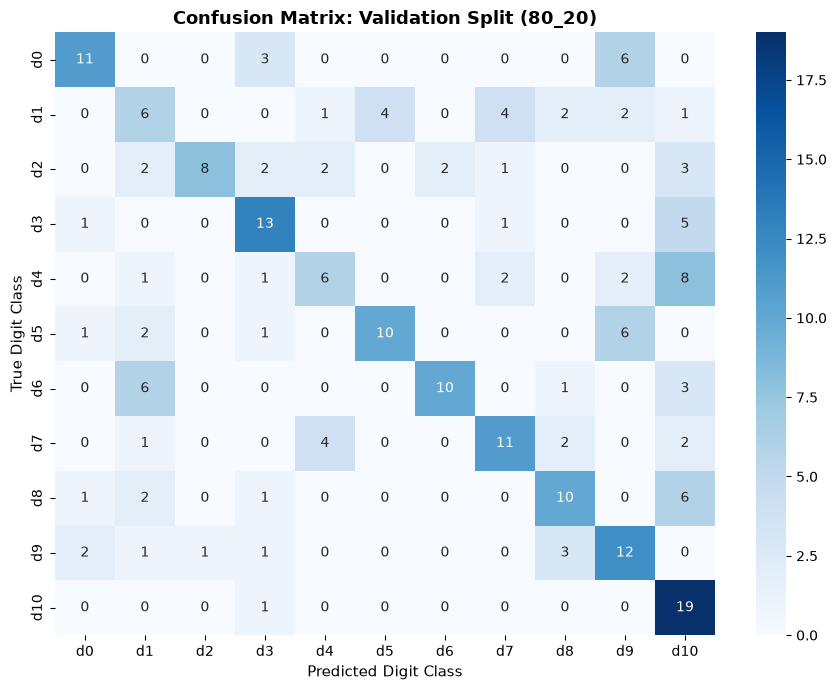

Validation confusion matrix saved to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/efficientnetb0_transformer_4block_80_20/confusion_matrix_validation_80_20.png


In [16]:
# Section 16: Final Validation Evaluation
val_loss, val_acc = model.evaluate(X_val, y_val, batch_size=BATCH_SIZE, verbose=1)

print("=" * 80)
print(f"                     VALIDATION SET EVALUATION [Mode: {DATASET_MODE}]")
print("=" * 80)
print(f"Validation Loss             : {val_loss:.4f}")
print(f"Validation Accuracy         : {val_acc * 100:.2f}%")
print(f"Validation Base Speakers ({len(base_val_speakers)}) : {base_val_speakers}")
print("=" * 80)


# Validation Confusion Matrix
val_probs = model.predict(X_val, batch_size=BATCH_SIZE, verbose=1)
val_preds = np.argmax(val_probs, axis=1)

cm_val = confusion_matrix(y_val, val_preds)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_val,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=DIGIT_CLASSES,
    yticklabels=DIGIT_CLASSES,
    cbar=True
)
plt.title(f"Confusion Matrix: Validation Split ({DATASET_MODE})", fontsize=13, fontweight="bold")
plt.xlabel("Predicted Digit Class", fontsize=11)
plt.ylabel("True Digit Class", fontsize=11)
plt.tight_layout()

val_cm_path = RESULTS_DIR / f"confusion_matrix_validation_{DATASET_MODE}.png"
plt.savefig(val_cm_path, dpi=200)
plt.show()
print(f"Validation confusion matrix saved to: {val_cm_path}")

## 17. Final Test Evaluation
> **STRICT PROTOCOL NOTICE**: The test set (`X_test`, `y_test`) is evaluated **strictly once** here at the conclusion of both training stages. It was completely isolated during model design, checkpointing, and hyperparameter decisions.

In [17]:
# Section 17: Isolated Final Test Evaluation
if DATASET_MODE == "80_20" or X_test is None:
    print("=" * 80)
    print(f"DATASET_MODE: {DATASET_MODE}")
    print("Test evaluation: DISABLED (no test split)")
    print("=" * 80)
    test_acc, test_prec, test_rec, test_f1 = None, None, None, None
    test_preds = None
else:
    test_probs = model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
    test_preds = np.argmax(test_probs, axis=1)

    test_acc = float(accuracy_score(y_test, test_preds))
    test_prec = float(precision_score(y_test, test_preds, average="macro", zero_division=0))
    test_rec = float(recall_score(y_test, test_preds, average="macro", zero_division=0))
    test_f1 = float(f1_score(y_test, test_preds, average="macro", zero_division=0))

    print("=" * 80)
    print("                   FINAL TEST SET EVALUATION SUMMARY")
    print("=" * 80)
    print(f"  Test Accuracy         : {test_acc * 100:.2f}%  ({int((test_preds == y_test).sum())}/{len(y_test)} correct)")
    print(f"  Macro Precision       : {test_prec:.4f}")
    print(f"  Macro Recall          : {test_rec:.4f}")
    print(f"  Macro F1-Score        : {test_f1:.4f}")
    print(f"  Validation Accuracy   : {val_acc * 100:.2f}%")
    print(f"  Validation Loss       : {val_loss:.4f}")
    print(f"  Total Parameters      : {model.count_params():,}")
    print(f"  Trainable Parameters  : {stage2_trainable_params:,}")
    print("=" * 80)

DATASET_MODE: 80_20
Test evaluation: DISABLED (no test split)


## 18. Classification Report
Generating and saving per-class precision, recall, and F1 scores for digits $d_0$ through $d_{10}$.

In [18]:
# Section 18: Classification Report
if test_preds is not None and y_test is not None:
    clf_report = classification_report(
        y_test,
        test_preds,
        target_names=DIGIT_CLASSES,
        digits=4,
        zero_division=0
    )

    print(clf_report)

    report_path = RESULTS_DIR / f"classification_report_{DATASET_MODE}.txt"
    with open(report_path, "w") as f:
        f.write(clf_report)
    print(f"Classification report saved to: {report_path}")
else:
    print(f"DATASET_MODE: {DATASET_MODE} - Classification report skipped (no test split)")

DATASET_MODE: 80_20 - Classification report skipped (no test split)


## 19. Confusion Matrix
Visualizing predicted vs. ground-truth digit classifications across unseen test speakers.

In [19]:
# Section 19: Confusion Matrix
if test_preds is not None and y_test is not None:
    cm = confusion_matrix(y_test, test_preds)

    plt.figure(figsize=(9, 7))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=DIGIT_CLASSES,
        yticklabels=DIGIT_CLASSES,
        cbar=True
    )
    plt.title(f"Confusion Matrix: EfficientNetB0 + 4-Block Transformer ({DATASET_MODE})", fontsize=13, fontweight="bold")
    plt.xlabel("Predicted Digit Class", fontsize=11)
    plt.ylabel("True Digit Class", fontsize=11)
    plt.tight_layout()

    cm_path = RESULTS_DIR / f"confusion_matrix_{DATASET_MODE}.png"
    plt.savefig(cm_path, dpi=200)
    plt.show()
    print(f"Confusion matrix saved to: {cm_path}")
else:
    print(f"DATASET_MODE: {DATASET_MODE} - Confusion matrix skipped (no test split)")

DATASET_MODE: 80_20 - Confusion matrix skipped (no test split)


## 20. Save Results
Exporting test predictions CSV and the consolidated experiment metrics JSON file to `results/efficientnetb0_transformer_4block/`.

In [20]:
# Section 20: Save Results Artifacts
if test_preds is not None and "test" in df_manifest["split"].values:
    test_manifest = df_manifest[df_manifest["split"] == "test"].copy().reset_index(drop=True)
    test_manifest["predicted_digit"] = [ID_TO_CLASS[p] for p in test_preds]
    test_manifest["predicted_id"] = test_preds
    test_manifest["correct"] = (test_manifest["digit_id"] == test_manifest["predicted_id"])

    test_predictions_csv = RESULTS_DIR / f"test_predictions_{DATASET_MODE}.csv"
    test_manifest[["speaker", "base_speaker", "digit", "digit_id", "predicted_digit", "predicted_id", "correct"]].to_csv(
        test_predictions_csv, index=False
    )
    print(f"Test predictions saved to: {test_predictions_csv}")

final_metrics = {
    "model_name": "EfficientNetB0_Transformer_4Block",
    "temporal_head": "Transformer_4x_4heads_256dim",
    "dataset_mode": DATASET_MODE,
    "dataset_dir": str(DATA_DIR),
    "seed": SEED,
    "num_train_folders": len(train_speakers),
    "num_base_train_speakers": len(base_train_speakers),
    "num_val_folders": len(val_speakers),
    "num_base_val_speakers": len(base_val_speakers),
    "num_test_folders": len(test_speakers),
    "num_base_test_speakers": len(base_test_speakers),
    "stage1": {
        "best_epoch": stage1_best_epoch,
        "best_val_loss": stage1_best_val_loss,
        "best_val_accuracy": stage1_best_val_acc,
        "learning_rate": STAGE1_LR,
        "max_epochs": STAGE1_MAX_EPOCHS,
        "patience": STAGE1_PATIENCE,
    },
    "stage2": {
        "best_epoch": stage2_best_epoch,
        "best_val_loss": stage2_best_val_loss,
        "best_val_accuracy": stage2_best_val_acc,
        "fine_tune_fraction": FINE_TUNE_FRACTION,
        "learning_rate": STAGE2_LR,
        "max_epochs": STAGE2_MAX_EPOCHS,
        "patience": STAGE2_PATIENCE,
    },
    "final_validation": {
        "loss": float(val_loss),
        "accuracy": float(val_acc),
    },
    "final_test": {
        "accuracy": float(test_acc) if test_acc is not None else None,
        "macro_precision": float(test_prec) if test_prec is not None else None,
        "macro_recall": float(test_rec) if test_rec is not None else None,
        "macro_f1": float(test_f1) if test_f1 is not None else None,
        "correct_predictions": int((test_preds == y_test).sum()) if test_preds is not None else None,
        "total_test_samples": int(len(y_test)) if y_test is not None else None,
    } if test_acc is not None else "DISABLED",
    "parameters": {
        "total_params": int(model.count_params()),
        "stage2_trainable_params": int(stage2_trainable_params),
    }
}

metrics_json_path = RESULTS_DIR / f"metrics_{DATASET_MODE}.json"
with open(metrics_json_path, "w") as f:
    json.dump(final_metrics, f, indent=2)
print(f"Final metrics JSON saved to: {metrics_json_path}")

Final metrics JSON saved to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/efficientnetb0_transformer_4block_80_20/metrics_80_20.json


## 21. Final Experiment Summary
Architectural comparison table across the three core temporal modeling experiments:

| Architectural Component | MobileNetV2 + BiLSTM (Baseline) | MobileNetV2 + 2-Block Transformer | EfficientNetB0 + 4-Block Transformer (This Experiment) |
| :--- | :--- | :--- | :--- |
| **Visual Frontend** | MobileNetV2 (ImageNet weights) | MobileNetV2 (ImageNet weights) | **EfficientNetB0 (ImageNet weights)** |
| **Temporal Head** | Bidirectional LSTM (64 units) | 2× Transformer Encoder Blocks | **4× Transformer Encoder Blocks** |
| **Attention Mechanism** | Recurrent hidden state propagation | Multi-Head Self-Attention (4 heads) | Multi-Head Self-Attention (4 heads) |
| **Attention Key Dim** | N/A | 64 | 64 |
| **FFN Dimension** | N/A | 512 (GELU) | 512 (GELU) |
| **Sequence Pooling** | Last hidden state | GlobalAveragePooling1D | GlobalAveragePooling1D |
| **Stage 1 Protocol** | Frozen CNN, Adam (lr=1e-4), EarlyStopping | Frozen CNN, Adam (lr=1e-4), EarlyStopping | Frozen CNN, Adam (lr=1e-4), EarlyStopping |
| **Stage 2 Protocol** | Unfreeze top 20%, BatchNorm frozen, Adam (lr=1e-5) | Unfreeze top 20%, BatchNorm frozen, Adam (lr=1e-5) | Unfreeze top 20%, BatchNorm frozen, Adam (lr=1e-5) |
| **Loss Function** | Label Smoothing ($0.1$) | Categorical Crossentropy | Label Smoothing ($0.1$) |
| **Validation Speakers** | `s1`, `s4`, `s21` (clean) | `s1`, `s4`, `s21` (clean) | `s1`, `s4`, `s21` (clean) |
| **Test Speakers** | `s8`, `s9`, `s24` (unseen) | `s8`, `s9`, `s24` (unseen) | `s8`, `s9`, `s24` (unseen) |

In [21]:
# Section 21: Final Experiment Summary Printout
print("=" * 60)
print(f"FINAL EVALUATION SUMMARY: EfficientNetB0 + 4-Block Transformer [{DATASET_MODE}]")
print("=" * 60)
if test_acc is not None:
    print(f"Test Accuracy:        {test_acc * 100:.2f}%")
    print(f"Macro Precision:      {test_prec:.4f}")
    print(f"Macro Recall:         {test_rec:.4f}")
    print(f"Macro F1-Score:       {test_f1:.4f}")
else:
    print(f"Test Evaluation:      DISABLED ({DATASET_MODE} mode)")
print(f"Validation Accuracy:  {val_acc * 100:.2f}%")
print(f"Validation Loss:      {val_loss:.4f}")
print(f"Total Parameters:     {model.count_params():,}")
print(f"Trainable Parameters: {stage2_trainable_params:,}")
print("=" * 60)

FINAL EVALUATION SUMMARY: EfficientNetB0 + 4-Block Transformer [80_20]
Test Evaluation:      DISABLED (80_20 mode)
Validation Accuracy:  52.73%
Validation Loss:      2.0307
Total Parameters:     6,489,006
Trainable Parameters: 4,726,939
